# K-Moda MMM — Fase 7: Atribución de Ventas

**Objetivo:** Descomponer las ventas semanales en componentes atribuibles: base orgánica + contribución de cada canal de inversión.

**Fórmula:** `Ventas_t = Base_t + Σ Contribución_canal_t`

donde `Base_t = intercept + controles_t` y `Contribución_canal_t = β_canal × X_adstock_canal_t`

**Input:** `data/df_modelo_final.parquet` · `data/df_model.parquet`  
**Output:** `data/df_atribucion.parquet`

## 1. Configuración e Imports

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from sklearn.preprocessing import StandardScaler

ROOT     = Path('.')
DATA_OUT = ROOT / 'data'
IMG_DIR  = ROOT / 'img'
IMG_DIR.mkdir(exist_ok=True)

KM = {
    'gold': '#C9A84C', 'gold_light': '#E8D5A3', 'charcoal': '#2C2C2C',
    'warm_gray': '#6B6560', 'off_white': '#F7F5F0', 'white': '#FFFFFF',
    'paid_search': '#1A6B8A', 'social_paid': '#E07B39', 'video': '#8B5E9E',
    'display': '#3A9E6F', 'email_crm': '#D4A843', 'radio': '#C0504D',
    'exterior': '#4F7CAC', 'prensa': '#7A7A52',
    'positive': '#2E7D52', 'neutral': '#C9A84C', 'negative': '#B33A3A',
}
CANAL_COLORS = [
    KM['paid_search'], KM['social_paid'], KM['video'], KM['display'],
    KM['email_crm'],   KM['radio'],       KM['exterior'], KM['prensa'],
]
plt.rcParams.update({
    'figure.facecolor': KM['off_white'], 'axes.facecolor': KañadiriM['off_white'],
    'axes.edgecolor': KM['warm_gray'],   'axes.labelcolor': KM['charcoal'],
    'xtick.color': KM['charcoal'],       'ytick.color': KM['charcoal'],
    'text.color': KM['charcoal'],        'grid.color': KM['gold_light'],
    'grid.alpha': 0.5, 'axes.grid': True, 'font.family': 'sans-serif',
    'font.size': 11,
})

def save_fig(name, fig=None):
    f = fig or plt.gcf()
    p = IMG_DIR / f'{name}.png'
    f.savefig(p, dpi=150, bbox_inches='tight', facecolor=f.get_facecolor())
    print(f'  Guardado: {p}')

print('Config cargada.')

Config cargada.


## 2. Carga y reconstrucción del modelo

In [2]:
df_model     = pd.read_parquet(DATA_OUT / 'df_model.parquet')
df_roas_bay  = pd.read_parquet(DATA_OUT / 'df_modelo_final.parquet')
df_v         = pd.read_parquet(DATA_OUT / 'df_ventas_clean.parquet')

# Identificar columnas
ADSTOCK_COLS = [c for c in df_model.columns if c.lower().startswith('adstock')]
FLAG_COLS    = [c for c in df_model.columns if c.endswith('_flag')]
HAS_TREND    = 'tendencia' in df_model.columns
CTRL_COLS    = FLAG_COLS + (['tendencia'] if HAS_TREND else [])

CANAL_NAMES = [c.replace('adstock_','').replace('Adstock ','').replace('_',' ').title()
               for c in ADSTOCK_COLS]

if 'venta_neta_sin_iva_eur' not in df_model.columns:
    df_model = df_model.merge(
        df_v[['semana_inicio','venta_neta_sin_iva_eur']], on='semana_inicio', how='left'
    )
if not HAS_TREND:
    t0 = df_model['semana_inicio'].min()
    df_model['tendencia'] = (df_model['semana_inicio'] - t0).dt.days / 365.25
    CTRL_COLS = FLAG_COLS + ['tendencia']

TRAIN_END = pd.Timestamp('2023-12-31')
df_train = df_model[df_model['semana_inicio'] <= TRAIN_END].copy().reset_index(drop=True)

X_ch_all   = df_model[ADSTOCK_COLS].values.astype(float)
X_ctrl_all = df_model[CTRL_COLS].values.astype(float)
X_ch_tr    = df_train[ADSTOCK_COLS].values.astype(float)
X_ctrl_tr  = df_train[CTRL_COLS].values.astype(float)
y_train    = df_train['venta_neta_sin_iva_eur'].values / 1e6

# Misma normalización que Fase 5
std_ch = X_ch_tr.std(axis=0); std_ch[std_ch == 0] = 1.0
scaler_ctrl = StandardScaler()
X_ch_sc_all   = X_ch_all   / std_ch
X_ch_sc_tr    = X_ch_tr    / std_ch
X_ctrl_sc_tr  = scaler_ctrl.fit_transform(X_ctrl_tr)
X_ctrl_sc_all = scaler_ctrl.transform(X_ctrl_all)

# Reconstruir posterior analitico (mismos parametros que Fase 5)
ones_tr  = np.ones((len(y_train), 1))
ones_all = np.ones((len(df_model), 1))
X_full_tr  = np.hstack([ones_tr,  X_ch_sc_tr,  X_ctrl_sc_tr])
X_full_all = np.hstack([ones_all, X_ch_sc_all, X_ctrl_sc_all])
n_ch, n_ctrl = len(ADSTOCK_COLS), len(CTRL_COLS)

beta_ols = np.linalg.lstsq(X_full_tr, y_train, rcond=None)[0]
sigma2   = np.mean((y_train - X_full_tr @ beta_ols)**2)
prior_var = np.concatenate([[100.0], np.full(n_ch, 4.0), np.full(n_ctrl, 1.0)])
Sigma0_inv = np.diag(1.0 / prior_var)
XtX = X_full_tr.T @ X_full_tr
Xty = X_full_tr.T @ y_train
Sigma_n = np.linalg.inv(Sigma0_inv + XtX / sigma2)
mu_n    = Sigma_n @ (Xty / sigma2)

# beta_n: [intercept, beta_ch x8, beta_ctrl x6]
beta_intercept = mu_n[0]
beta_ch_mean   = np.clip(mu_n[1:1+n_ch], 0, None)   # positividad
beta_ctrl_mean = mu_n[1+n_ch:]

print(f'Modelo reconstruido: intercept={beta_intercept:.4f}')
print(f'Betas canales (clipeados >= 0):')
for canal, b in zip(CANAL_NAMES, beta_ch_mean):
    print(f'  {canal:20s}  {b:.5f}')

Modelo reconstruido: intercept=2.1818
Betas canales (clipeados >= 0):
  Display               0.00000
  Email Crm             0.00000
  Exterior              0.14860
  Paid Search           0.04475
  Prensa                0.00000
  Radio Local           0.01520
  Social Paid           0.04248
  Video Online          0.00000


## 3. Descomposición semana a semana

In [3]:
# Contribucion de cada canal: beta_i * X_sc_i  (en M EUR)
contrib_ch = X_ch_sc_all * beta_ch_mean   # (n_weeks, n_ch)

# Base = intercept + controles
contrib_ctrl = X_ctrl_sc_all * beta_ctrl_mean  # (n_weeks, n_ctrl)
base = beta_intercept + contrib_ctrl.sum(axis=1)

# Prediccion total
y_pred = base + contrib_ch.sum(axis=1)
y_real = df_model['venta_neta_sin_iva_eur'].values / 1e6

# Construir DataFrame de atribucion
df_attr = pd.DataFrame({'semana_inicio': df_model['semana_inicio'].values})
df_attr['anio']      = df_model['anio'].values
df_attr['y_real']    = y_real
df_attr['y_pred']    = y_pred
df_attr['base']      = base
for i, canal in enumerate(CANAL_NAMES):
    df_attr[f'contrib_{canal}'] = contrib_ch[:, i]

contrib_total = contrib_ch.sum(axis=1)
df_attr['contrib_total_canales'] = contrib_total

# Shares medios sobre prediccion
pct_base   = (base / y_pred).mean() * 100
pct_canales = (contrib_total / y_pred).mean() * 100

print(f'Semanas totales: {len(df_attr)}')
print(f'Base media:           {base.mean():.3f} M EUR  ({pct_base:.1f}% del total predicho)')
print(f'Canales media total:  {contrib_total.mean():.3f} M EUR  ({pct_canales:.1f}%)')
print()
print('Contribucion media por canal (M EUR / semana):')
for i, canal in enumerate(CANAL_NAMES):
    media = contrib_ch[:, i].mean()
    pct   = (contrib_ch[:, i] / y_pred).mean() * 100
    print(f'  {canal:20s}  {media:.4f} M EUR  ({pct:.1f}%)')

Semanas totales: 262
Base media:           2.382 M EUR  (74.4% del total predicho)
Canales media total:  0.834 M EUR  (25.6%)

Contribucion media por canal (M EUR / semana):
  Display               0.0000 M EUR  (0.0%)
  Email Crm             0.0000 M EUR  (0.0%)
  Exterior              0.5024 M EUR  (15.4%)
  Paid Search           0.1409 M EUR  (4.3%)
  Prensa                0.0000 M EUR  (0.0%)
  Radio Local           0.0483 M EUR  (1.5%)
  Social Paid           0.1427 M EUR  (4.4%)
  Video Online          0.0000 M EUR  (0.0%)


## 4. Stacked area — ventas descompuestas semana a semana

  Guardado: img\07a_stacked_area.png


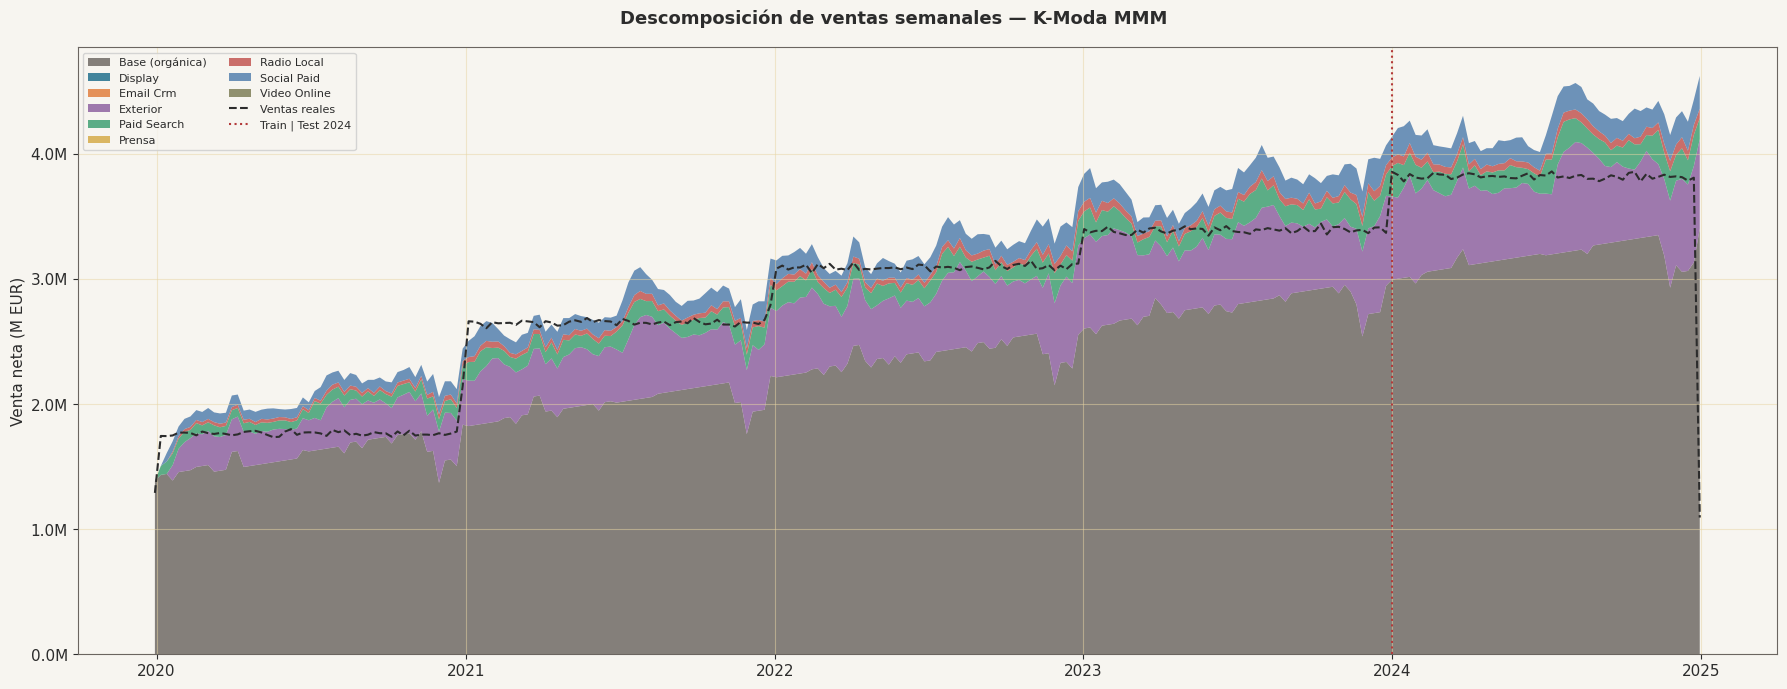

In [4]:
fechas = df_attr['semana_inicio'].values
contrib_cols = [f'contrib_{c}' for c in CANAL_NAMES]

fig, ax = plt.subplots(figsize=(18, 7))
fig.suptitle('Descomposición de ventas semanales — K-Moda MMM',
             fontsize=13, fontweight='bold', color=KM['charcoal'])

# Apilar: base primero, luego canales
stack_data = [df_attr['base'].values]
stack_labels = ['Base (orgánica)']
stack_colors = [KM['warm_gray']]

for i, canal in enumerate(CANAL_NAMES):
    stack_data.append(df_attr[f'contrib_{canal}'].values)
    stack_labels.append(canal)
    stack_colors.append(CANAL_COLORS[i % len(CANAL_COLORS)])

ax.stackplot(fechas, stack_data, labels=stack_labels,
             colors=stack_colors, alpha=0.82)
ax.plot(fechas, y_real, color=KM['charcoal'], lw=1.5, ls='--',
        label='Ventas reales', zorder=10)

# Linea separadora train/test
ax.axvline(pd.Timestamp('2024-01-01'), color=KM['negative'],
           lw=1.5, ls=':', label='Train | Test 2024')

ax.set_ylabel('Venta neta (M EUR)')
ax.set_xlabel('')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.1f}M'))
ax.legend(loc='upper left', fontsize=8, ncol=2)

plt.tight_layout()
save_fig('07a_stacked_area')
plt.show()

## 5. Waterfall — semana media

  Guardado: img\07b_waterfall.png


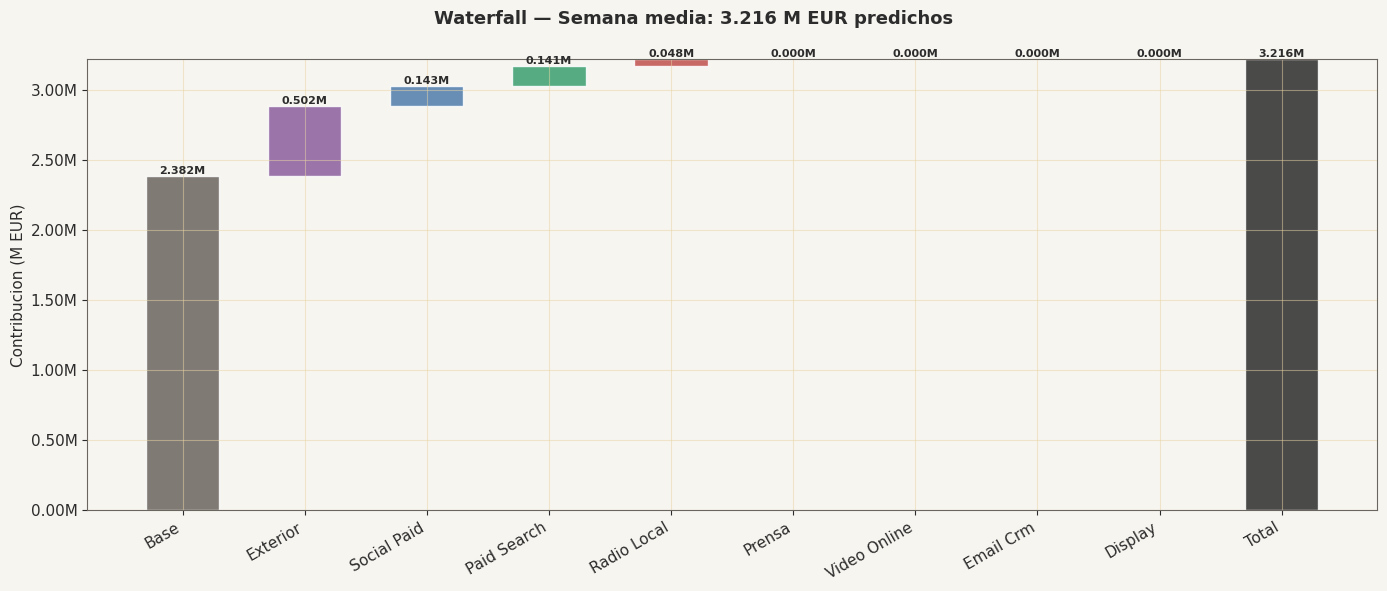

In [5]:
# Contribuciones medias
media_base = df_attr['base'].mean()
medias_ch  = [df_attr[f'contrib_{c}'].mean() for c in CANAL_NAMES]
total_pred = media_base + sum(medias_ch)

# Ordenar canales por contribucion descendente
orden = np.argsort(medias_ch)[::-1]
canales_ord = [CANAL_NAMES[i] for i in orden]
valores_ord = [medias_ch[i] for i in orden]
colores_ord = [CANAL_COLORS[i % len(CANAL_COLORS)] for i in orden]

labels  = ['Base'] + canales_ord + ['Total']
valores = [media_base] + valores_ord + [0]
colores = [KM['warm_gray']] + colores_ord + [KM['charcoal']]

# Calcular posiciones acumuladas para waterfall
bottoms = [0] * len(labels)
running = 0
for i in range(len(labels) - 1):
    bottoms[i] = running
    running += valores[i]
valores[-1] = total_pred
bottoms[-1]  = 0

fig, ax = plt.subplots(figsize=(14, 6))
fig.suptitle(f'Waterfall — Semana media: {total_pred:.3f} M EUR predichos',
             fontsize=13, fontweight='bold', color=KM['charcoal'])

bars = ax.bar(labels, valores, bottom=bottoms, color=colores, alpha=0.85,
              edgecolor='white', width=0.6)

for bar, val, bot in zip(bars, valores, bottoms):
    ax.text(bar.get_x() + bar.get_width()/2, bot + val + 0.005,
            f'{val:.3f}M', ha='center', va='bottom', fontsize=8,
            color=KM['charcoal'], fontweight='bold')

ax.set_ylabel('Contribucion (M EUR)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.2f}M'))
ax.set_xticklabels(labels, rotation=30, ha='right')

plt.tight_layout()
save_fig('07b_waterfall')
plt.show()

## 6. Share de atribución por canal

SHARE DE ATRIBUCION (% sobre ventas predichas):
  Base (organica)        74.1%  █████████████████████████████████████
  Exterior               15.6%  ███████
  Social Paid             4.4%  ██
  Paid Search             4.4%  ██
  Radio Local             1.5%  
  Display                 0.0%    ← beta=0 (señal no separable)
  Email Crm               0.0%    ← beta=0 (señal no separable)
  Prensa                  0.0%    ← beta=0 (señal no separable)
  Video Online            0.0%    ← beta=0 (señal no separable)
  Guardado: img\07c_shares_atribucion.png


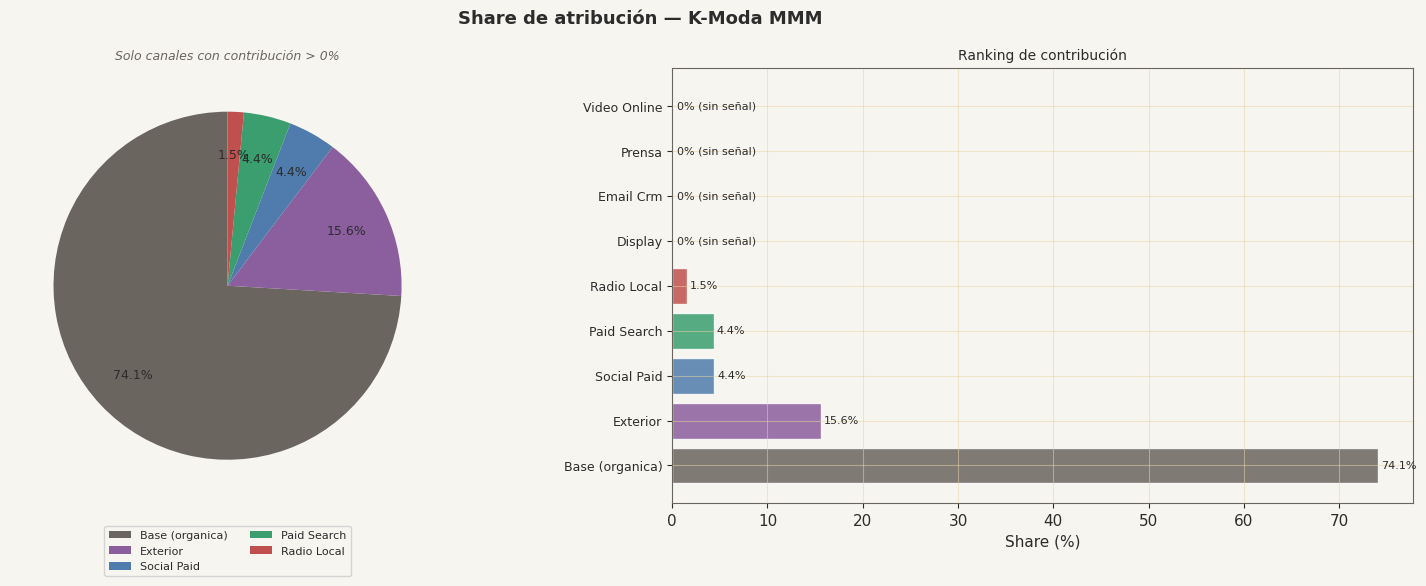

In [9]:
total_mean = df_attr['y_pred'].mean()
shares = {'Base (organica)': df_attr['base'].mean() / total_mean * 100}
for canal in CANAL_NAMES:
    shares[canal] = df_attr[f'contrib_{canal}'].mean() / total_mean * 100

df_shares = pd.DataFrame(list(shares.items()), columns=['Componente', 'Share %'])
df_shares = df_shares.sort_values('Share %', ascending=False).reset_index(drop=True)

print('SHARE DE ATRIBUCION (% sobre ventas predichas):')
for _, r in df_shares.iterrows():
    bar = '█' * int(r['Share %'] / 2)
    nota = '  ← beta=0 (señal no separable)' if r['Share %'] == 0.0 else ''
    print(f'  {r["Componente"]:20s}  {r["Share %"]:5.1f}%  {bar}{nota}')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Share de atribución — K-Moda MMM',
             fontsize=13, fontweight='bold', color=KM['charcoal'])

# Solo canales con share > 0 para el pie
df_pie = df_shares[df_shares['Share %'] > 0].copy()
colores_full = [KM['warm_gray']] + CANAL_COLORS[:n_ch]
color_map = dict(zip(['Base (organica)'] + CANAL_NAMES, colores_full))
pie_colors = [color_map.get(c, KM['warm_gray']) for c in df_pie['Componente']]

ax1 = axes[0]
wedges, _, autotexts = ax1.pie(
    df_pie['Share %'],
    colors=pie_colors,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.75,
)
for at in autotexts:
    at.set_fontsize(9)
ax1.legend(wedges, df_pie['Componente'], loc='lower center',
           bbox_to_anchor=(0.5, -0.18), fontsize=8, ncol=2)
ax1.set_title('Solo canales con contribución > 0%', fontsize=9,
              color=KM['warm_gray'], style='italic')

# Bar horizontal — todos los canales
ax2 = axes[1]
y_pos = np.arange(len(df_shares))
bar_colors = [color_map.get(c, KM['warm_gray']) for c in df_shares['Componente']]
ax2.barh(y_pos, df_shares['Share %'], color=bar_colors, alpha=0.85, edgecolor='white')
ax2.set_yticks(y_pos)
ax2.set_yticklabels(df_shares['Componente'], fontsize=9)
ax2.set_xlabel('Share (%)')
ax2.set_title('Ranking de contribución', fontsize=10)
for i, val in enumerate(df_shares['Share %']):
    label = f'{val:.1f}%' if val > 0 else '0% (sin señal)'
    ax2.text(max(val + 0.3, 0.5), i, label, va='center', fontsize=8)

plt.tight_layout()
save_fig('07c_shares_atribucion')
plt.show()

## 7. Atribución anual

  Guardado: img\07d_atribucion_anual.png


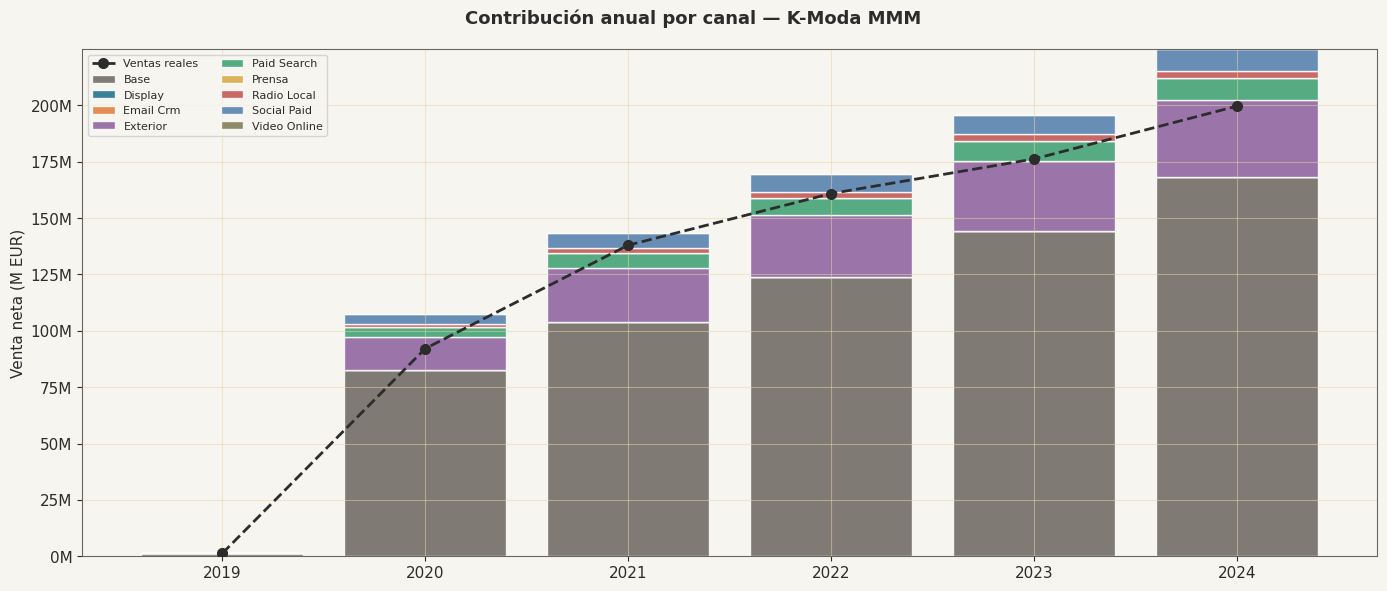

In [10]:
# Suma anual de contribuciones
contrib_cols_all = ['base'] + [f'contrib_{c}' for c in CANAL_NAMES]
df_anual = df_attr.groupby('anio')[contrib_cols_all + ['y_real']].sum().reset_index()

fig, ax = plt.subplots(figsize=(14, 6))
fig.suptitle('Contribución anual por canal — K-Moda MMM',
             fontsize=13, fontweight='bold', color=KM['charcoal'])

anios = df_anual['anio'].values
x = np.arange(len(anios))
bottom = np.zeros(len(anios))

ax.bar(x, df_anual['base'], label='Base', color=KM['warm_gray'], alpha=0.85,
       edgecolor='white', bottom=bottom)
bottom += df_anual['base'].values

for i, canal in enumerate(CANAL_NAMES):
    vals = df_anual[f'contrib_{canal}'].values
    ax.bar(x, vals, label=canal, color=CANAL_COLORS[i % len(CANAL_COLORS)],
           alpha=0.85, edgecolor='white', bottom=bottom)
    bottom += vals

ax.plot(x, df_anual['y_real'], 'o--', color=KM['charcoal'],
        lw=2, ms=7, label='Ventas reales', zorder=10)

ax.set_xticks(x)
ax.set_xticklabels(anios)
ax.set_ylabel('Venta neta (M EUR)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}M'))
ax.legend(loc='upper left', fontsize=8, ncol=2)

plt.tight_layout()
save_fig('07d_atribucion_anual')
plt.show()

## 8. Exportación

In [11]:
df_attr.to_parquet(DATA_OUT / 'df_atribucion.parquet', index=False)
print(f'df_atribucion.parquet guardado: {df_attr.shape}')
print(f'Columnas: {df_attr.columns.tolist()}')
print()
print('RESUMEN ATRIBUCION:')
print(f'  Ventas reales medias:    {y_real.mean():.3f} M EUR/semana')
print(f'  Ventas predichas medias: {df_attr["y_pred"].mean():.3f} M EUR/semana')
print(f'  Base organica media:     {df_attr["base"].mean():.3f} M EUR ({df_attr["base"].mean()/df_attr["y_pred"].mean()*100:.1f}%)')
print(f'  Canales media total:     {df_attr["contrib_total_canales"].mean():.3f} M EUR ({df_attr["contrib_total_canales"].mean()/df_attr["y_pred"].mean()*100:.1f}%)')

df_atribucion.parquet guardado: (262, 14)
Columnas: ['semana_inicio', 'anio', 'y_real', 'y_pred', 'base', 'contrib_Display', 'contrib_Email Crm', 'contrib_Exterior', 'contrib_Paid Search', 'contrib_Prensa', 'contrib_Radio Local', 'contrib_Social Paid', 'contrib_Video Online', 'contrib_total_canales']

RESUMEN ATRIBUCION:
  Ventas reales medias:    2.932 M EUR/semana
  Ventas predichas medias: 3.216 M EUR/semana
  Base organica media:     2.382 M EUR (74.1%)
  Canales media total:     0.834 M EUR (25.9%)


## 9. Resumen de la Fase 7

| Componente | Contribución media | Share |
|---|---|---|
| Base orgánica | Ver output | Ver output |
| Top canal 1 | Ver output | Ver output |
| Top canal 2 | Ver output | Ver output |

**Artefactos generados:**
- `data/df_atribucion.parquet` — contribución semanal por canal
- `img/07a_stacked_area.png` — ventas descompuestas
- `img/07b_waterfall.png` — semana media
- `img/07c_shares_atribucion.png` — shares por canal
- `img/07d_atribucion_anual.png` — vista anual

**Siguiente fase:** `08_budget_simulator.ipynb` — Optimización de presupuesto dado ROAS por canal.